# IEEE-CIS Fraud Detection — EDA
### Step 1: Data Loading

In [21]:
import pandas as pd

train_transaction = pd.read_csv('../data/train_transaction.csv')
train_identity = pd.read_csv('../data/train_identity.csv')

print("Transaction shape:", train_transaction.shape)
print("Identity shape:", train_identity.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


### Step 2: First Look at Data

In [22]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Step 3: Column Info & Data Types

In [23]:
train_transaction.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


### Step 4: Merge Transaction

#### Merge


In [24]:
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
print("Merged shape:", train.shape)

Merged shape: (590540, 434)


### Step 5: Check Fraud Ratio (Class Imbalance)

#### Fraud ratio

In [25]:
fraud_counts = train['isFraud'].value_counts()
fraud_percent = train['isFraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print("\nFraud %:\n", fraud_percent)

isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud %:
 isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


### Step 6: Missing Values Check

In [26]:
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100

missing_df = pd.DataFrame({'Missing Count': missing,'Missing %': missing_percent}).sort_values('Missing %', ascending=False)

print(missing_df.head(20))
print("\nTotal columns with >50% missing:", (missing_percent > 50).sum())

       Missing Count  Missing %
id_24         585793  99.196159
id_25         585408  99.130965
id_07         585385  99.127070
id_08         585385  99.127070
id_21         585381  99.126393
id_26         585377  99.125715
id_27         585371  99.124699
id_23         585371  99.124699
id_22         585371  99.124699
dist2         552913  93.628374
D7            551623  93.409930
id_18         545427  92.360721
D13           528588  89.509263
D14           528353  89.469469
D12           525823  89.041047
id_04         524216  88.768923
id_03         524216  88.768923
D6            517353  87.606767
id_33         517251  87.589494
id_09         515614  87.312290

Total columns with >50% missing: 214


### Step 7: Drop High-Missing Columns (>90%)

In [28]:
threshold = 0.9
cols_to_drop = missing_percent[missing_percent > (threshold * 100)].index
train_clean = train.drop(columns=cols_to_drop)

print("Columns dropped:", len(cols_to_drop))
print("Remaining shape:", train_clean.shape)

Columns dropped: 12
Remaining shape: (590540, 422)


### Step 8: Handle Remaining Missing Values

#### Numeric columns — fill missing values with median

In [29]:
numeric_cols = train_clean.select_dtypes(include=['float64', 'int64']).columns
train_clean[numeric_cols] = train_clean[numeric_cols].fillna(train_clean[numeric_cols].median())



#### Categorical/string columns — fill missing values with 'unknown'

In [30]:
categorical_cols = train_clean.select_dtypes(include=['object']).columns
train_clean[categorical_cols] = train_clean[categorical_cols].fillna('unknown')


C:\Users\vaibh\AppData\Local\Temp\ipykernel_62804\1453738502.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_clean.select_dtypes(include=['object']).columns


##### Confirm no missing values left

In [ ]:
print("Total missing values remaining:", train_clean.isnull().sum().sum())

Total missing values remaining: 0


### Step 9: Encode Categorical Columns

In [32]:
from sklearn.preprocessing import LabelEncoder
import joblib

categorical_cols = train_clean.select_dtypes(include=['object', 'str']).columns
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train_clean[col] = le.fit_transform(train_clean[col].astype(str))
    encoders[col] = le

joblib.dump(encoders, '../models/encoders.pkl')
print("Encoding done, encoders saved")

Encoding done, encoders saved


### Step 10: Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X = train_clean.drop(columns=['isFraud', 'TransactionID'])
y = train_clean['isFraud']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Fraud % in train:", y_train.mean() * 100)
print("Fraud % in test:", y_test.mean() * 100)

X_train shape: (472432, 420)
X_test shape: (118108, 420)
Fraud % in train: 3.498916246147594
Fraud % in test: 3.49933958749619


### Step 11: Train Baseline Model (with Class Weights)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

c:\Users\vaibh\OneDrive\Desktop\fraud-detection-app\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.98      0.65      0.79    113975
           1       0.07      0.70      0.13      4133

    accuracy                           0.66    118108
   macro avg       0.53      0.68      0.46    118108
weighted avg       0.95      0.66      0.76    118108

ROC-AUC Score: 0.7528952099226279


### Step 12: Train Random Forest Model

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier( n_estimators=100, class_weight='balanced', max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96    113975
           1       0.27      0.74      0.40      4133

    accuracy                           0.92    118108
   macro avg       0.63      0.83      0.68    118108
weighted avg       0.96      0.92      0.94    118108

ROC-AUC Score: 0.9162389674704536


### Step 13: Save the Model

In [36]:
import joblib
joblib.dump(rf_model, '../models/fraud_model.pkl')
print("Model saved successfully")

Model saved successfully


### Step 14: Visualizations

##### Fraud vs Legit Distribution


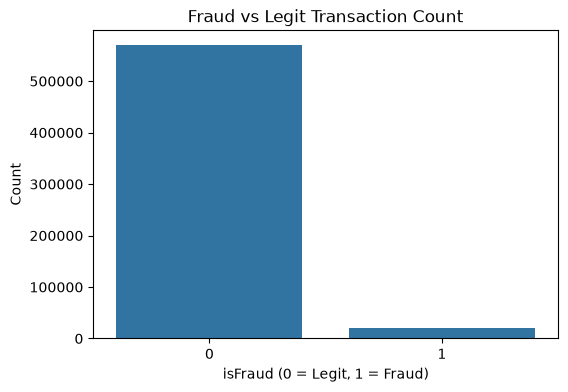

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=train_clean)
plt.title('Fraud vs Legit Transaction Count')
plt.xlabel('isFraud (0 = Legit, 1 = Fraud)')
plt.ylabel('Count')
plt.savefig('../visualizations/fraud_distribution.png')
plt.show()

##### ~570,000 legit vs ~20,000 fraud transactions - imbalance visually confirmed.

#### Feature Importance (Random Forest - top 15 features)

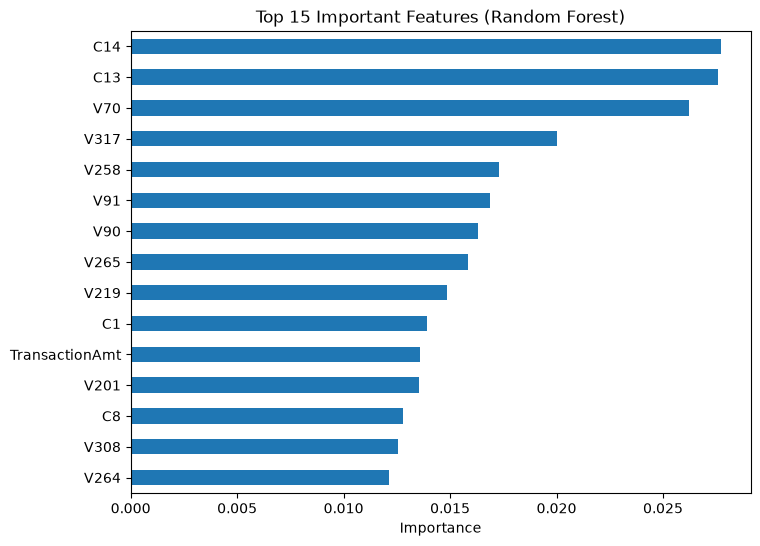

In [41]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.plot(kind='barh')
plt.title('Top 15 Important Features (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.savefig('../visualizations/feature_importance.png')
plt.show()

##### Top features: C14, C13, V70, V317, V258 — mostly anonymized columns (actual meaning unknown, Kaggle privacy constraint).
##### Transaction amt matters, but not top-ranked.

#### Confusion Matrix

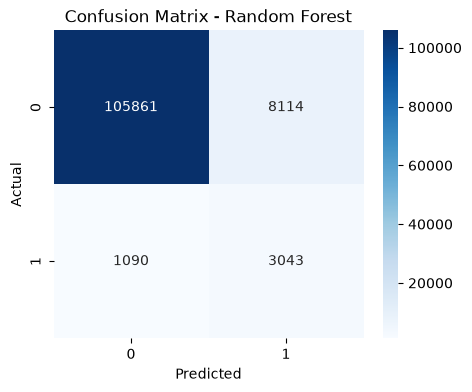

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../visualizations/confusion_matrix.png')
plt.show()

##### Caught 3,043 of 4,133 frauds (74% recall).
##### 8,114 legit transactions wrongly flagged as fraud (precision issue).
##### Trade-off: high recall (catches most fraud), low precision (many false alarms).



In [44]:
print(X_train.columns.tolist())
print(len(X_train.columns))

['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V8

### Step 15: Save Default Values for Auto-Fill

In [45]:
import joblib

defaults = X_train.median(numeric_only=True).to_dict()
joblib.dump(defaults, '../models/default_values.pkl')

joblib.dump(list(X_train.columns), '../models/column_order.pkl')

print("Defaults and column order saved")

Defaults and column order saved


### Step 16: Flask App - Main Backend (app.py) ###


In [1]:
from flask import Flask, render_template, request
import joblib
import pandas as pd

app = Flask(__name__)

##### Load saved model and helper files

In [3]:
model = joblib.load('../models/fraud_model.pkl')
defaults = joblib.load('../models/default_values.pkl')
column_order = joblib.load('../models/column_order.pkl')
encoders = joblib.load('../models/encoders.pkl')

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    amount = float(request.form['amount'])
    product_cd = request.form['product_cd']
    card4 = request.form['card4']
    card6 = request.form['card6']
    email_domain = request.form['email_domain']

    input_data = defaults.copy()

    input_data['TransactionAmt'] = amount
    input_data['ProductCD'] = encoders['ProductCD'].transform([product_cd])[0]
    input_data['card4'] = encoders['card4'].transform([card4])[0]
    input_data['card6'] = encoders['card6'].transform([card6])[0]
    input_data['P_emaildomain'] = encoders['P_emaildomain'].transform([email_domain])[0]

    input_df = pd.DataFrame([input_data])[column_order]

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    result = "FRAUD" if prediction == 1 else "LEGIT"
    return render_template('index.html', prediction=result, probability=round(probability*100, 2))

if __name__ == '__main__':
    app.run(debug=False)

AssertionError: View function mapping is overwriting an existing endpoint function: home